**Taller 4 - Selección de modelos**

Diego Andrés Burbano A.


## 1. Importar librerias necesarias para el modelo

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

import os
from google.colab import drive

## 2. Carga de datos

In [3]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Revisión preliminar de datos

In [4]:
data = pd.read_csv('./train.csv', sep=',')
data.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


In [5]:
#Cantidad y dimensionalidad de los datos
data.shape

(42100, 19)

In [6]:
#Perfilamiento de los datos
data.describe()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000,42100.000000
mean,21049.500000,1.920713,0.141093,0.884632,2.398005,0.239192,0.025249,0.428931,103.888029,2017.856295,7.593539,15.902945,0.728504,0.029192,0.019715,0.175772,104.566377,0.571734,0.392019
std,12153.367503,0.524950,0.450128,0.885693,1.427330,0.587674,0.156884,0.832605,81.069343,0.350795,2.829395,8.888582,0.633529,0.168347,0.325837,1.732121,37.139165,0.775041,0.488207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10524.750000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,37.000000,2018.000000,6.000000,8.000000,0.000000,0.000000,0.000000,0.000000,80.000000,0.000000,0.000000
50%,21049.500000,2.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,93.000000,2018.000000,8.000000,16.000000,1.000000,0.000000,0.000000,0.000000,99.450000,0.000000,0.000000
75%,31574.250000,2.000000,0.000000,2.000000,3.000000,0.000000,0.000000,1.000000,155.000000,2018.000000,10.000000,24.000000,1.000000,0.000000,0.000000,0.000000,123.300000,1.000000,1.000000
max,42099.000000,4.000000,9.000000,7.000000,17.000000,3.000000,1.000000,6.000000,443.000000,2018.000000,12.000000,31.000000,4.000000,1.000000,13.000000,58.000000,540.000000,5.000000,1.000000


Eliminamos la columna 'id' por considerar que la misma no aporta valor al modelo:

In [7]:
data = data.drop(columns=['id'])

In [8]:
#Revisión de datos faltantes
print(f'Datos nulos: \n {data.isna().sum()}')

Datos nulos: 
 no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


No existen datos faltantes o nulos.

In [9]:
#Identificación de datos repetidos
print(f'Datos duplicados: {data.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

##3. Preparación de los sets de entrenamiento

In [10]:
X_train = data.drop('booking_status',axis=1)
y_train =data['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

##4. Modelo 1: Arbol de decisión

Modelo inicial - linea base para comparar con el modelo cambiando los hiperparámetros.

El accuracy de entrenamiento es: 0.990055423594616
El accuracy prueba es: 0.7361520190023753


Text(50.722222222222214, 0.5, 'Verdad')

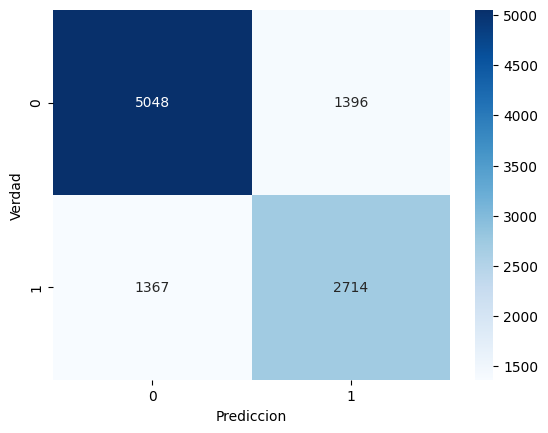

In [29]:
#Creación del modelo
max_depth0 = 40
d_tree=DecisionTreeClassifier(max_depth=max_depth0)

#Entrenamiento del modelo
d_tree.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train0=d_tree.predict(X_train)

#Métricas de desempeño
accuracy_train0 = accuracy_score(y_train, y_pred_train0)
print (f"El accuracy de entrenamiento es: {accuracy_train0}")

#Predicción de los datos de prueba
y_pred_ds0=d_tree.predict(X_test)

#Métricas de desempeño
accuracy_ds0 = accuracy_score(y_test, y_pred_ds0)
print (f"El accuracy prueba es: {accuracy_ds0}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

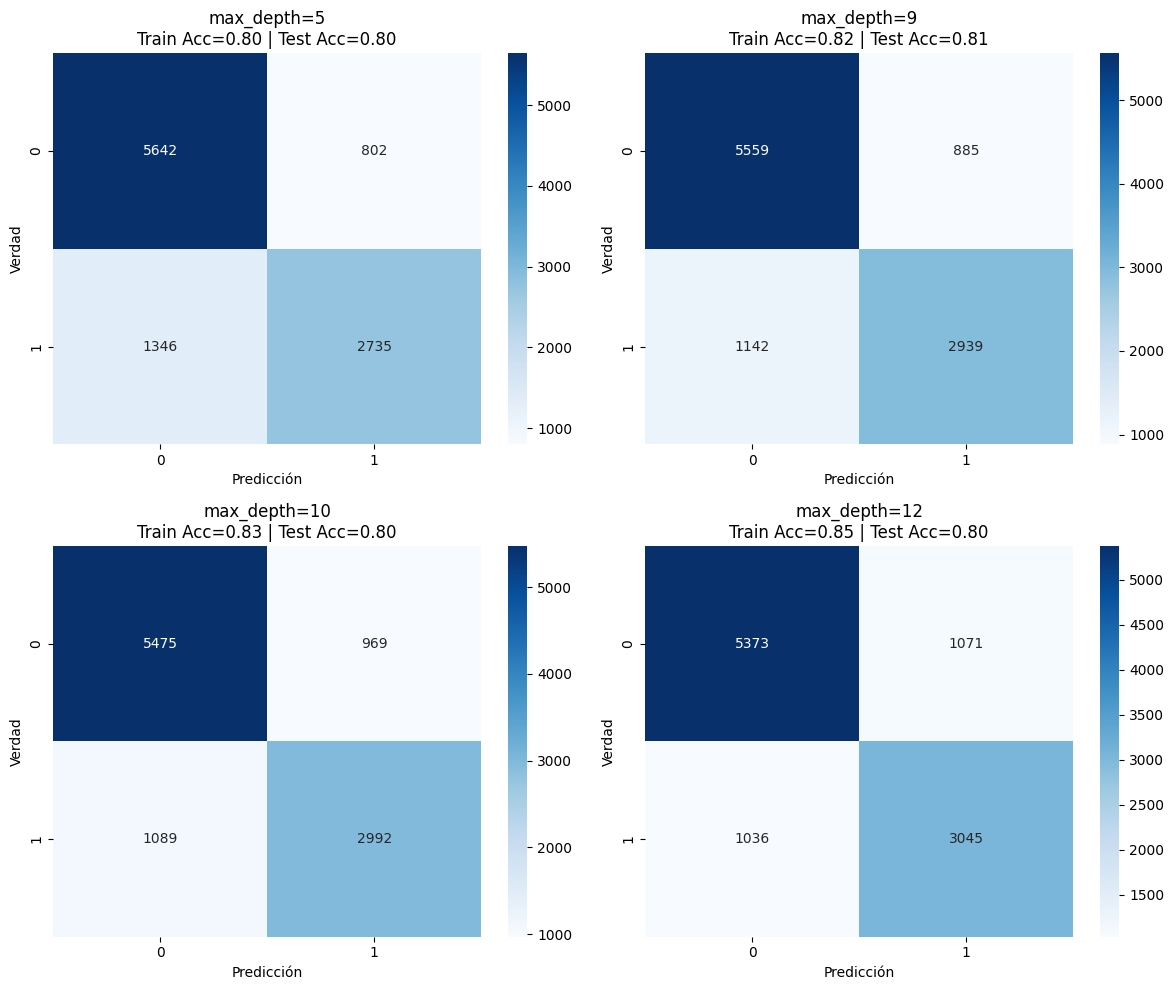

   max_depth  accuracy_train  accuracy_test
0          5        0.796200       0.795914
1          9        0.820966       0.807411
2         10        0.827743       0.804466
3         12        0.847791       0.799810
4         40        0.990055       0.736152


In [30]:
parametros_dt = [5, 9, 10, 12]
resultados = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, i in enumerate(parametros_dt):
    d_tree = DecisionTreeClassifier(max_depth=i, random_state=0)
    d_tree.fit(X_train, y_train)

    y_pred_train = d_tree.predict(X_train)
    accuracy_train = accuracy_score(y_train, y_pred_train)

    y_pred_test = d_tree.predict(X_test)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    resultados.append({
        "max_depth": i,
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test
    })

    sns.heatmap(confusion_matrix(y_test, y_pred_test),
                annot=True, fmt='g', cmap='Blues',
                ax=axes[idx])

    axes[idx].set_title(
        f"max_depth={i}\nTrain Acc={accuracy_train:.2f} | Test Acc={accuracy_test:.2f}"
    )
    axes[idx].set_xlabel("Predicción")
    axes[idx].set_ylabel("Verdad")

plt.tight_layout()
plt.show()
resultados.append({
    "max_depth": max_depth0,
    "accuracy_train": accuracy_train0,
    "accuracy_test": accuracy_ds0
})

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

##5. Modelo 2: Regresión Lineal

Modelo inicial - linea base para comparar con el modelo cambiando los hiperparámetros.

El accuracy de entrenamiento es: 0.7536658749010293
El accuracy de prueba es: 0.7565795724465558


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(50.722222222222214, 0.5, 'Verdad')

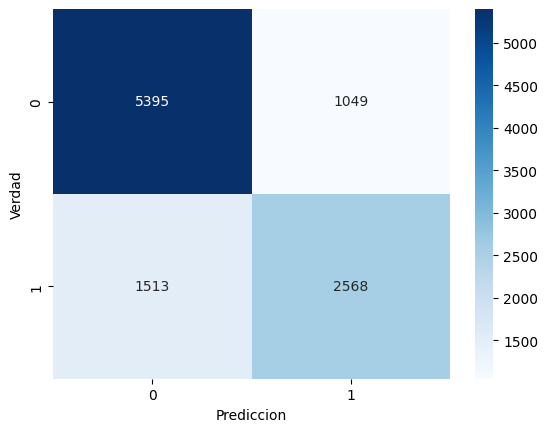

In [43]:
# Crear el modelo
model = LogisticRegression()

#Entrenamiento del modelo
model.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train=model.predict(X_train)

#Métricas de desempeño
accuracy_train_rl_0=accuracy_score(y_train, y_pred_train)
print (f"El accuracy de entrenamiento es: {accuracy_train_rl_0}")

#Predicción de los datos de prueba
y_pred_ds=model.predict(X_test)

#Métricas de desempeño
accuracy_prueba0=accuracy_score(y_test, y_pred_ds)
print (f"El accuracy de prueba es: {accuracy_prueba0}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

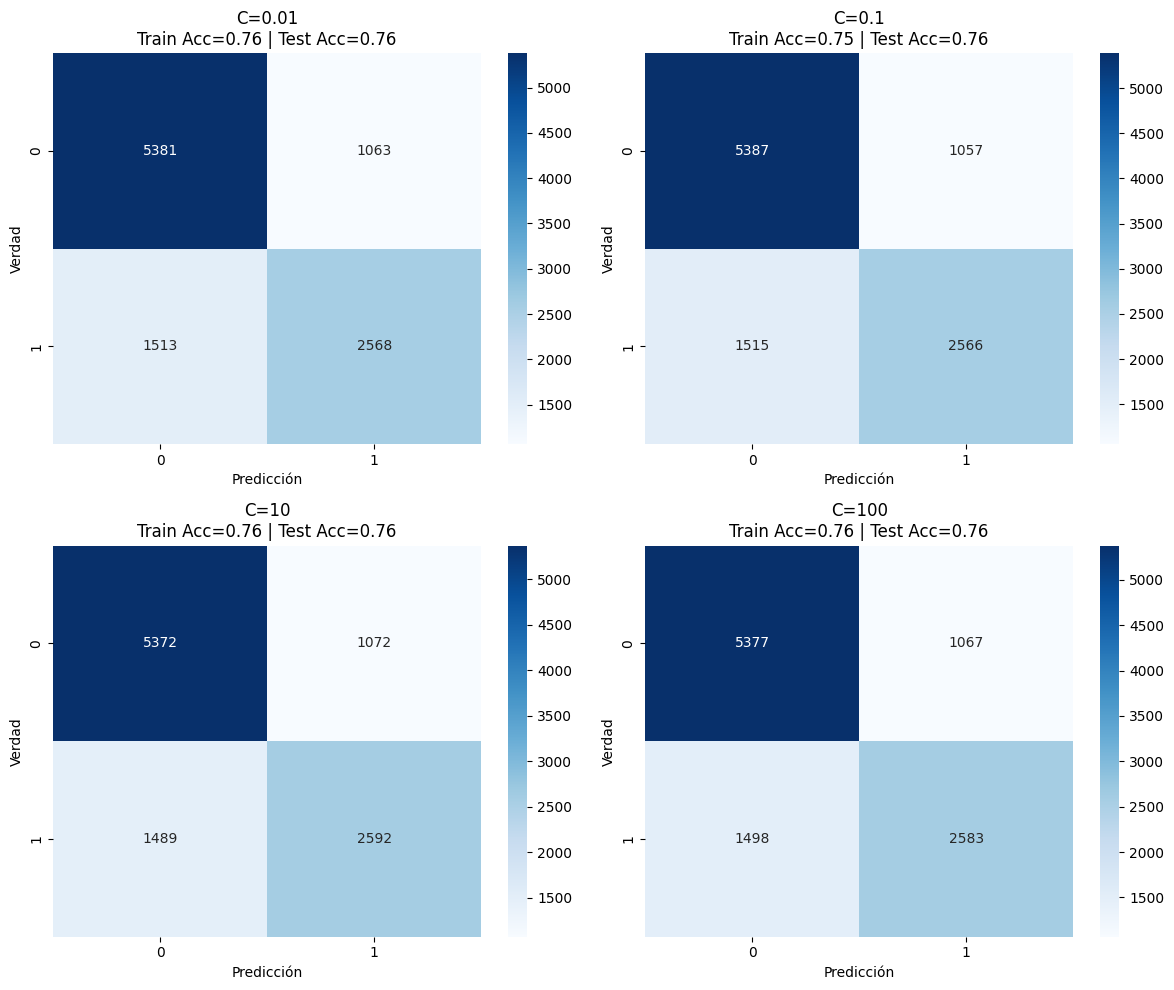

        C  accuracy_train  accuracy_test
0    0.01        0.756516       0.755249
1    0.10        0.753698       0.755629
2   10.00        0.758321       0.756675
3  100.00        0.758733       0.756295
4    1.00        0.753666       0.756580


In [52]:
parametros_rl = [0.01, 0.1, 10, 100]
resultados_rl = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, i in enumerate(parametros_rl):
    model = LogisticRegression(C=i)

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    accuracy_train = accuracy_score(y_train, y_pred_train)

    y_pred_test = model.predict(X_test)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    resultados_rl.append({
        "C": i,
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test
    })

    sns.heatmap(confusion_matrix(y_test, y_pred_test),
                annot=True, fmt='g', cmap='Blues',
                ax=axes[idx])
    axes[idx].set_title(
        f"C={i}\nTrain Acc={accuracy_train:.2f} | Test Acc={accuracy_test:.2f}"
    )
    axes[idx].set_xlabel("Predicción")
    axes[idx].set_ylabel("Verdad")

plt.tight_layout()
plt.show()

resultados_rl.append({
    "C": 1,
    "accuracy_train": accuracy_train_rl_0,
    "accuracy_test": accuracy_prueba0
})

df_resultados_rl = pd.DataFrame(resultados_rl)
print(df_resultados_rl)


##6. Resultados y Conclusiones

Responda la siguientes preguntas:

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
3. De las variaciones que aplicó el modelo de Arbol de desición ¿Cuál fué el modelo con mejor desempeño?

**Respuestas**:

En la medida que aumentamos la complejidad del modelo de arbol de decisión permitiendo al modelo profundizar mas incrementando su profundidad, vemos que el modelo es mas complejo y aprende cada vez mas del conjunto de entrenamiento hasta alcanzar overfitting (sobreajuste). Lo anterior se evidencia en que en la medida que aumenta el hiperparámetro profundidad (max_depth) la precisión del modelo de entrenamiento aumenta hasta alcanzar 0.99 en detrimento de su capacidad de generalización.

El sobreajuste se puede apreciar a partir del max_depth igual a 12, es decir para los modelos max_depth = 12 y 40. Vemos como para esos modelos el valor del accuracy de test es 0.7998 y 0.736152 respectivamente. Estos valores caen a partir del máximo que alcanza el modelo para un valor de max_depth = 9, donde el accuracy para el set de prueba alcanza un máximo en 0.8074, punto de equilibrio entre sesgo y varianza, resultando éste como el modelo con el mejor desempeño.



Responda la siguientes preguntas:

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
Teniendo en cuenta los modelos de árbol de desición y regresión logística ¿Cuál fué el modelo con mejor desempeño?Justifique su respuesta
3. ¿De que otra manera cree que podría mejorar el desempeño de cada uno de los modelos trabajados durante este taller?


**Respuestas**:

Podemos concluir con los resultados del modelo de regresión lineal, que este modelo en particular con los datos con los que fue entrenado y probado no es sensible a modificaciones del parámetro C con el cual controlamos la regularización (o mejor la inversa de la regularización), ya que con cambios significativos en este parámetro, apenas si se presentan cambios en el resultado del accuracy del modelo. Por lo tanto, el modelo esta dominado por las características del dataset, mas que por la regularización en sí misma.

De otro lado, tambien es posible concluir que al presentar valores bastante similares en el accuracy entre los datos de entrenamiento y pruebas, que el modelo no muestra indicios de subajuste o sobreajuste, y por el contrario con base en los resultados, se concluye que el modelo esta generalizando bien.

Comparando los resultados de los dos modelos, vemos que el modelo que presenta mejor desempeño, basado en las metricas de accuracy, es el arbol de decisión con una profundidad de 9 niveles. Este modelo es el que presenta menor cantidad de falsos positivos y falsos negativos en la matriz de decisión. Lo anterior va en linea con la premisa que para set de datos pequeños, como este es el caso, modelos muy complejos van a tender a generar sobreajuste, preferiendo para estos casos modelos mas sencillos con hiperparámetros con niveles mas bajos.

Recomendaciones generales para mejorar el resultado de los modelos:
1. Incrementar el volumen de datos podría permitir que modelos más complejos, como la regresión logística, alcancen un mejor desempeño al aprovechar de manera más efectiva sus características y lograr una mejor capacidad de generalización. Esto se debe a que modelos más complejos requieren un mayor número de muestras para estimar correctamente sus parámetros y evitar tanto el subajuste como el sobreajuste.
2. Desarrollar un pipeline que nos permita para ambos modelos encontrar el mejor conjunto de hiperparámetros a través del cual evaluamos no solo el accuracy sino incluir otros parámetros precision, recall o F1, este último especialmente cuando contamos con clases desbalanceadas.
3. Igualmente podriamos probar validación cruzada (k-fold o estratificada) para estimar mejor el desempeño y reducir la dependencia en una partición del conjunto de datos.

